Sorry, I thought this was supposed to be on paper. I realized after Problem 3 😭

## Problem 1

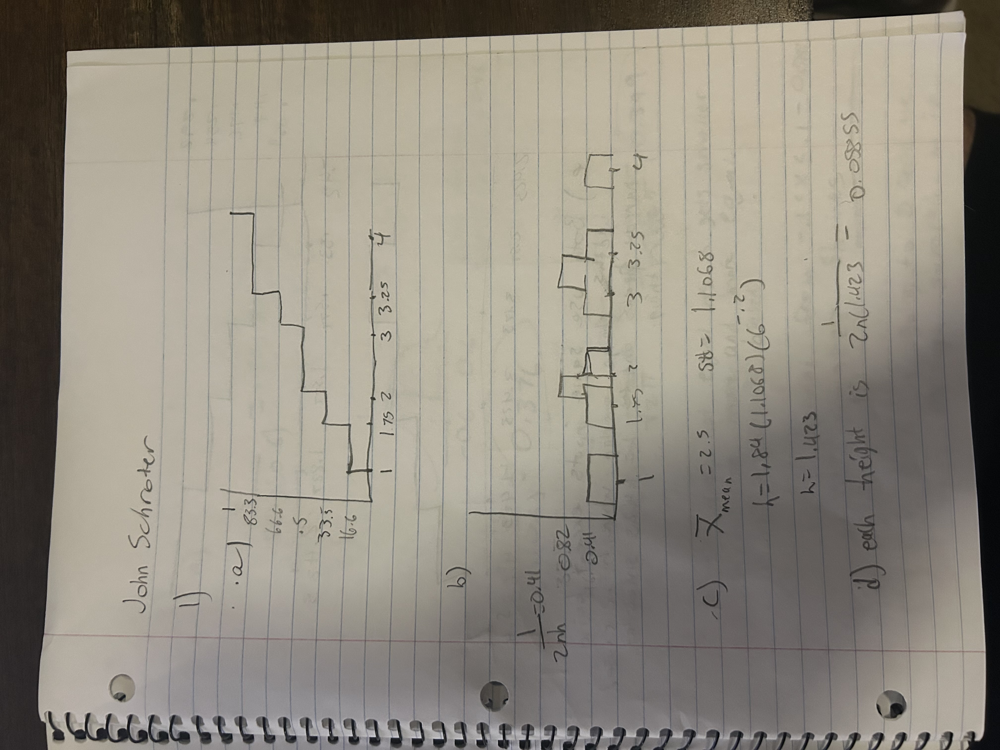

## Problem 1 — continued

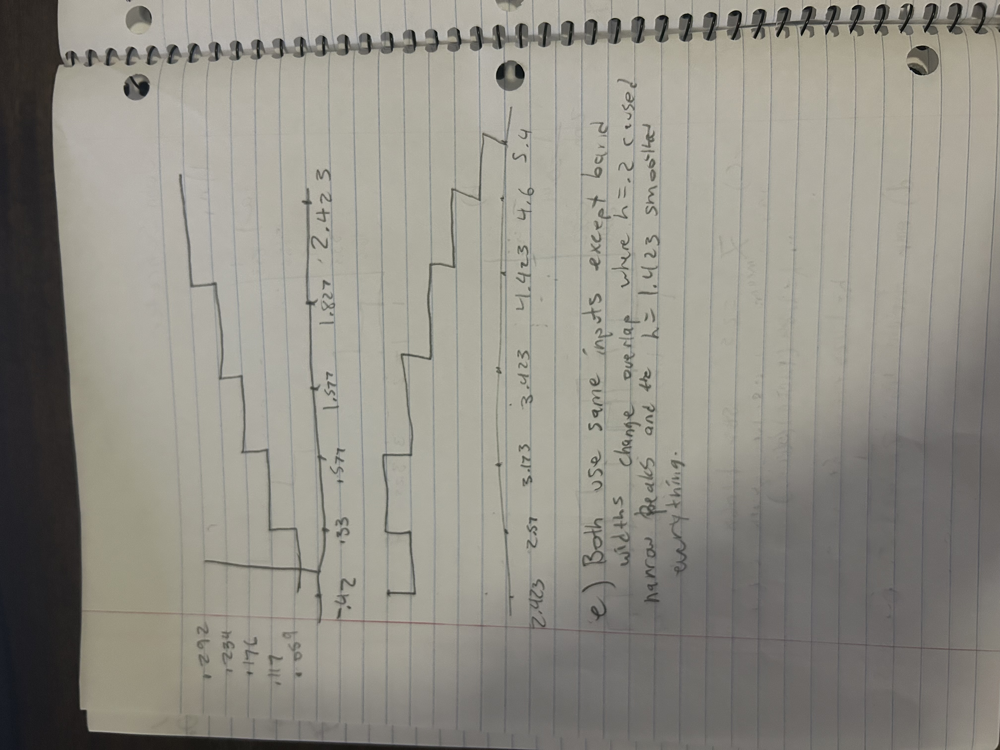

## Problem 2

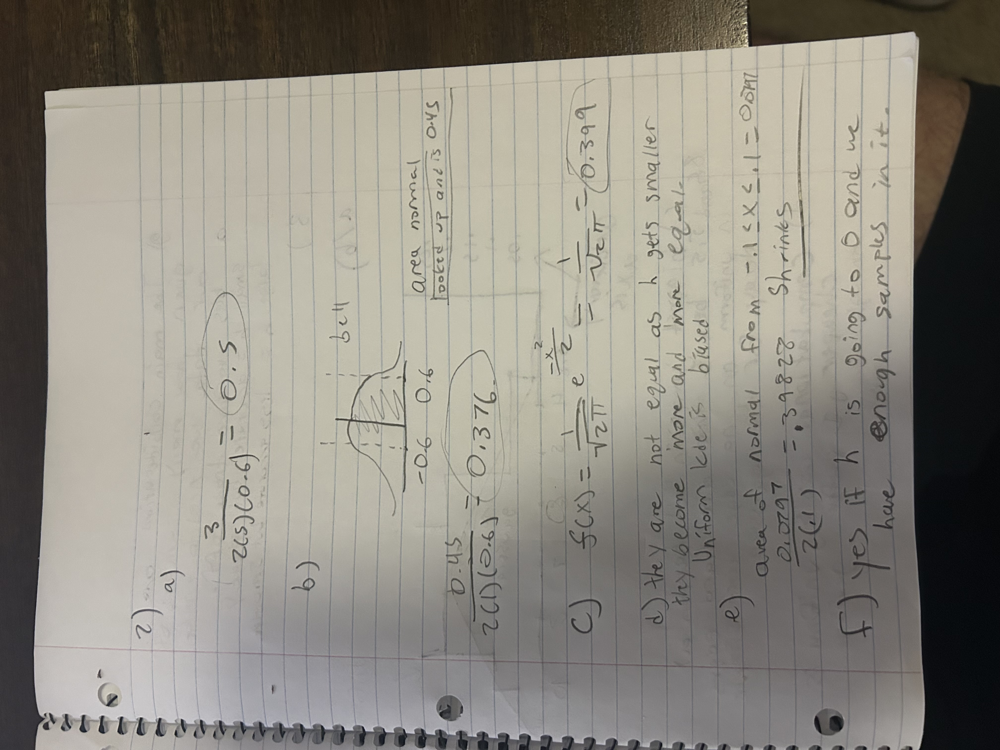

## Problem 2(g) and Problem 3

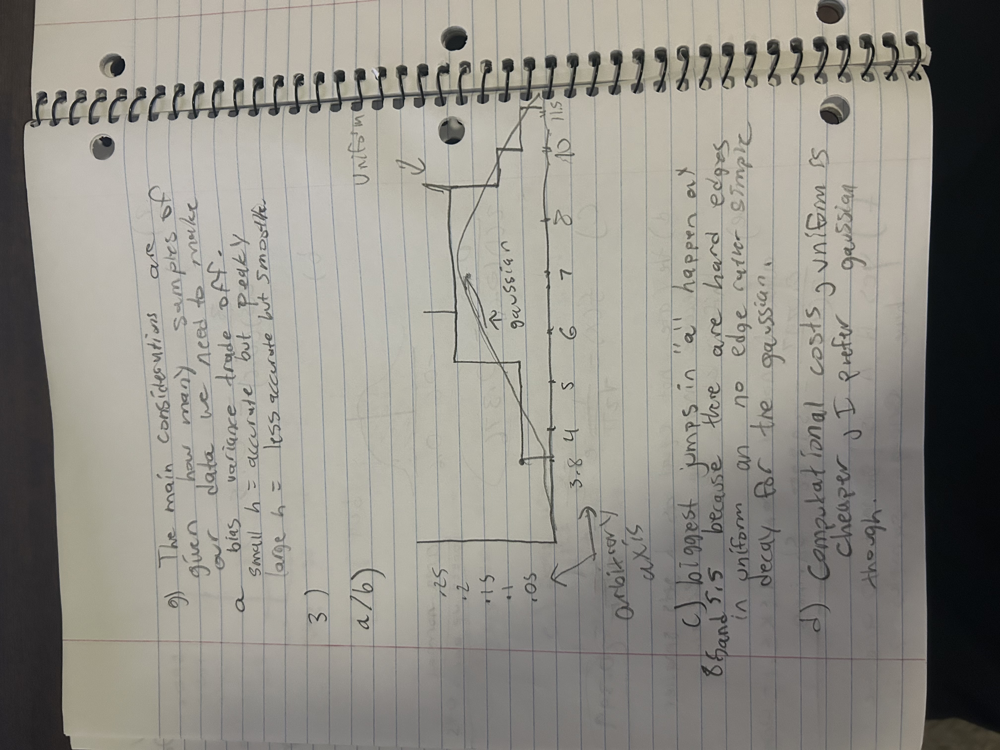

## Problem 4 (used ai for the code portion)

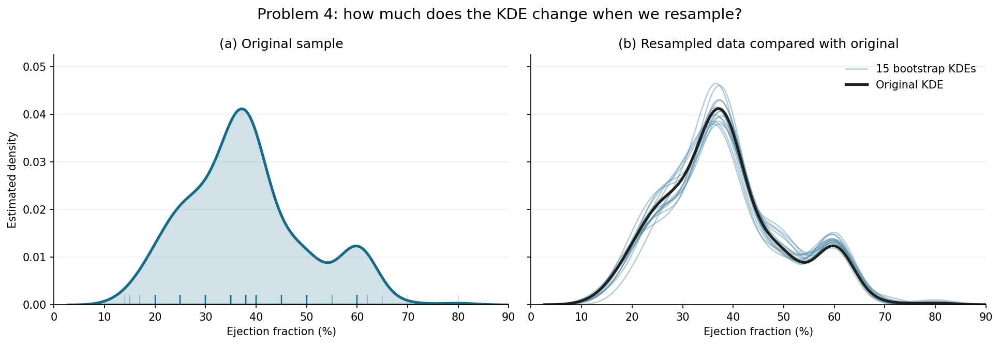

In [2]:
# Problem 4: original KDE and 15 bootstrap KDEs
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Support running from the repository root or the ThursdayLab folder.
data_path = Path("./data/heart_failure_clinical_records_dataset.csv")
if not data_path.is_file():
    data_path = Path("../data/heart_failure_clinical_records_dataset.csv")
df = pd.read_csv(data_path)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)

# (a) Estimate the density using all original observations.
sns.kdeplot(data=df, x="ejection_fraction", ax=axes[0],
            color="#176b87", fill=True, alpha=0.2, linewidth=2.5,
            clip=(0, 100))
sns.rugplot(data=df, x="ejection_fraction", ax=axes[0],
            color="#176b87", alpha=0.2, height=0.04)
axes[0].set_title("(a) Original sample")

# (b) Each bootstrap sample has the same size, drawn with replacement.
for seed in range(15):
    sample = df.sample(frac=1.0, replace=True, random_state=seed)
    sns.kdeplot(data=sample, x="ejection_fraction", ax=axes[1],
                color="#548ca8", alpha=0.45, linewidth=1.2,
                clip=(0, 100),
                label="15 bootstrap KDEs" if seed == 0 else None)

sns.kdeplot(data=df, x="ejection_fraction", ax=axes[1],
            color="#202020", linewidth=2.5, clip=(0, 100),
            label="Original KDE")
axes[1].set_title("(b) Resampled data compared with original")
axes[1].legend(frameon=False)

for ax in axes:
    ax.set(xlabel="Ejection fraction (%)", ylabel="Estimated density",
           xlim=(0, 90))
    ax.grid(axis="y", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Problem 4: how much does the KDE change when we resample?", fontsize=14)
fig.tight_layout()
plt.show()


4c) overall the samples do vary however the overall structure appears relatively consistent with the peaks being in largely the same spots. The tails have less data so I cant tell but they also look pretty similar. The most variation starts happening at the peak being 35ish%.